# KỸ THUẬT TRÍCH CHỌN ĐẶC TRƯNG + TIỀN XỬ LÝ DỮ LIỆU

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dữ liệu (nếu chưa load)
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
# Lưu PassengerId của test set để submit sau
test_ids = test_df['PassengerId'].copy()

In [3]:
# Ghi nhớ kích thước tập huấn luyện ban đầu
TRAIN_SIZE = len(train_df)

## 1. Xử lý đặc trưng

### A. Phân tích Tên (Name) và Danh xưng (Title)

In [4]:
train_fe = train_df.copy()
test_fe = test_df.copy()
combine_df = pd.concat([train_fe, test_fe], ignore_index=True)

In [5]:
# 1. Trích xuất Title từ cột Name
combine_df['Title'] = combine_df['Name'].str.extract(r'([A-Za-z]+)\.', expand=False)

# 2. Hiển thị phân bố Title
print("\nPhân bố các danh xưng (Title) ban đầu:\n", combine_df['Title'].value_counts())


Phân bố các danh xưng (Title) ban đầu:
 Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Mlle          2
Major         2
Ms            2
Lady          1
Sir           1
Mme           1
Don           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64



Tỷ lệ sống sót theo Danh xưng (Title):
 Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Rare      0.347826
Mr        0.156673
Name: Survived, dtype: float64


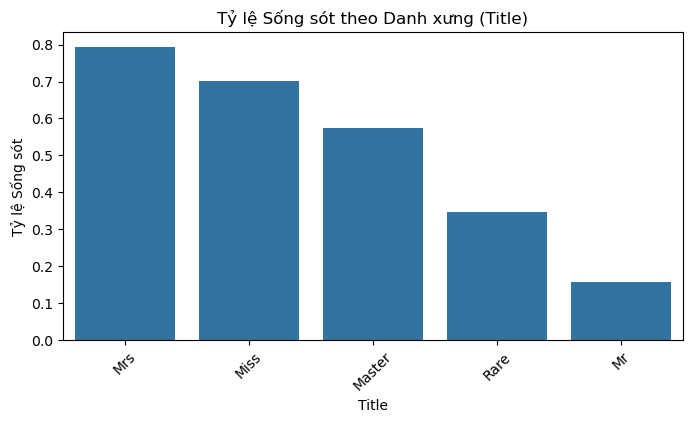

In [6]:
# 3. Gom nhóm các danh xưng hiếm gặp (Rare Title)
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
combine_df['Title'] = combine_df['Title'].replace(rare_titles, 'Rare')
combine_df['Title'] = combine_df['Title'].replace('Mlle', 'Miss')
combine_df['Title'] = combine_df['Title'].replace('Ms', 'Miss')
combine_df['Title'] = combine_df['Title'].replace('Mme', 'Mrs')

# Phân tích tỷ lệ sống sót theo Title (chỉ dùng tập huấn luyện)
train_with_fe = combine_df.iloc[:TRAIN_SIZE].copy()
train_with_fe['Survived'] = train_df['Survived'] # Gán lại cột Survived (để đảm bảo không bị NaN)

title_survival = train_with_fe.groupby('Title')['Survived'].mean().sort_values(ascending=False)
print("\nTỷ lệ sống sót theo Danh xưng (Title):\n", title_survival)

# Trực quan hóa
plt.figure(figsize=(8, 4))
sns.barplot(x=title_survival.index, y=title_survival.values)
plt.title('Tỷ lệ Sống sót theo Danh xưng (Title)')
plt.ylabel('Tỷ lệ Sống sót')
plt.xticks(rotation=45)
plt.show()

### B. Phân tích Gia đình (FamilySize) và Đi một mình (IsAlone)


Tỷ lệ sống sót theo Kích thước Gia đình (FamilySize):
 FamilySize
4     0.724138
3     0.578431
2     0.552795
7     0.333333
1     0.303538
5     0.200000
6     0.136364
8     0.000000
11    0.000000
Name: Survived, dtype: float64


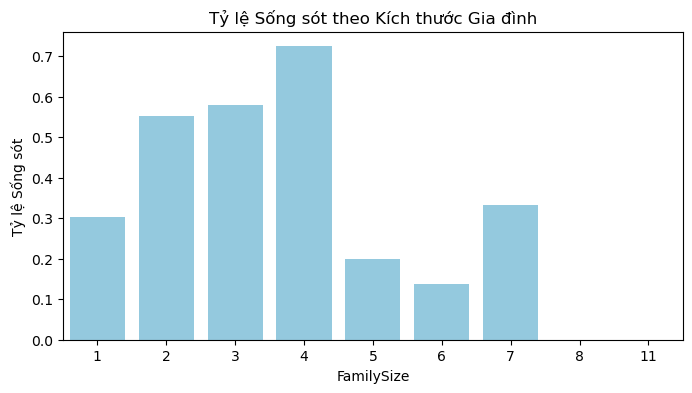

In [7]:
# 1. Tạo FamilySize = SibSp + Parch + 1 (trên tập gộp)
combine_df['FamilySize'] = combine_df['SibSp'] + combine_df['Parch'] + 1

# 2. Tạo IsAlone (trên tập gộp)
combine_df['IsAlone'] = np.where(combine_df['FamilySize'] == 1, 1, 0)

# Cập nhật train_with_fe với các cột FE mới
train_with_fe = combine_df.iloc[:TRAIN_SIZE].copy()
train_with_fe['Survived'] = train_df['Survived'] # Gán lại cột Survived

# Phân tích tỷ lệ sống sót theo FamilySize
family_survival = train_with_fe.groupby('FamilySize')['Survived'].mean().sort_values(ascending=False)
print("\nTỷ lệ sống sót theo Kích thước Gia đình (FamilySize):\n", family_survival)

# Trực quan hóa FamilySize
plt.figure(figsize=(8, 4))
sns.barplot(x=family_survival.index, y=family_survival.values, color='skyblue')
plt.title('Tỷ lệ Sống sót theo Kích thước Gia đình')
plt.ylabel('Tỷ lệ Sống sót')
plt.show()


Tỷ lệ sống sót theo Đi một mình (IsAlone):
 IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


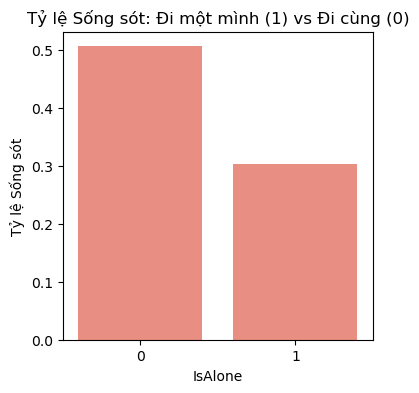

In [8]:
# Phân tích tỷ lệ sống sót theo IsAlone
alone_survival = train_with_fe.groupby('IsAlone')['Survived'].mean().sort_values(ascending=False)
print("\nTỷ lệ sống sót theo Đi một mình (IsAlone):\n", alone_survival)

# Trực quan hóa IsAlone
plt.figure(figsize=(4, 4))
sns.barplot(x=alone_survival.index, y=alone_survival.values, color='salmon')
plt.title('Tỷ lệ Sống sót: Đi một mình (1) vs Đi cùng (0)')
plt.ylabel('Tỷ lệ Sống sót')
plt.show()

### C. Phân tích Cabin Deck


Tỷ lệ sống sót theo Boong tàu (Cabin_Deck):
 Cabin_Deck
D    0.757576
E    0.750000
B    0.744681
F    0.615385
C    0.593220
G    0.500000
A    0.466667
U    0.299854
T    0.000000
Name: Survived, dtype: float64


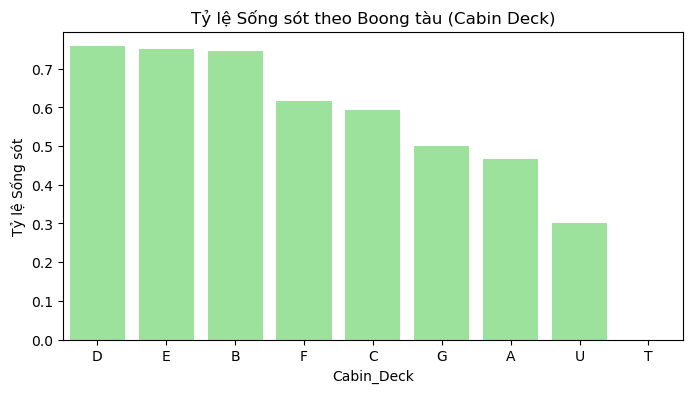

In [9]:
# Điền giá trị 'U' (Unknown) cho Cabin bị thiếu (trên tập gộp)
combine_df['Cabin'] = combine_df['Cabin'].fillna('U')

# 1. Tạo Cabin_Deck (lấy ký tự đầu tiên) (trên tập gộp)
combine_df['Cabin_Deck'] = combine_df['Cabin'].str[0]

# Cập nhật train_with_fe
train_with_fe = combine_df.iloc[:TRAIN_SIZE].copy()
train_with_fe['Survived'] = train_df['Survived'] # Gán lại cột Survived

# Phân tích tỷ lệ sống sót theo Cabin_Deck
cabin_survival = train_with_fe.groupby('Cabin_Deck')['Survived'].mean().sort_values(ascending=False)
print("\nTỷ lệ sống sót theo Boong tàu (Cabin_Deck):\n", cabin_survival)

# Trực quan hóa Cabin_Deck
plt.figure(figsize=(8, 4))
sns.barplot(x=cabin_survival.index, y=cabin_survival.values, color='lightgreen')
plt.title('Tỷ lệ Sống sót theo Boong tàu (Cabin Deck)')
plt.ylabel('Tỷ lệ Sống sót')
plt.show()

### D. Tách lại tập dữ liệu sau khi thêm các cột FE
 (Sử dụng tập combine_df cuối cùng)

In [10]:
train_fe_df = combine_df.iloc[:TRAIN_SIZE].copy()
train_fe_df['Survived'] = train_df['Survived']
test_fe_df = combine_df.iloc[TRAIN_SIZE:].copy()
test_fe_df = test_fe_df.drop('Survived', axis=1) # Loại bỏ cột Survived chỉ chứa NaN

print("\n--- Hoàn thành các bước Feature Engineering và Phân tích bổ sung ---")
print("Tập train đã có thêm các cột: Title, FamilySize, IsAlone, Cabin_Deck.")
print("\nKiểm tra các cột của train_fe_df:\n", train_fe_df.columns)


--- Hoàn thành các bước Feature Engineering và Phân tích bổ sung ---
Tập train đã có thêm các cột: Title, FamilySize, IsAlone, Cabin_Deck.

Kiểm tra các cột của train_fe_df:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'Title', 'FamilySize',
       'IsAlone', 'Cabin_Deck'],
      dtype='object')


# 2. Tiền xử lý dữ liệu

In [11]:
# --- 1. Xử lý Embarked (2 giá trị thiếu trong tập train) ---
# Dùng mode (giá trị phổ biến nhất)
embarked_mode = combine_df['Embarked'].mode()[0]
combine_df['Embarked'] = combine_df['Embarked'].fillna(embarked_mode)
print(f"-> Cột Embarked đã được điền bằng MODE: {embarked_mode}")

-> Cột Embarked đã được điền bằng MODE: S


In [12]:
# --- 2. Xử lý Fare (1 giá trị thiếu trong tập test) ---
# Dùng median của Pclass tương ứng (thường là Pclass=3)
fare_median_p3 = combine_df[combine_df['Pclass'] == 3]['Fare'].median()
combine_df['Fare'] = combine_df['Fare'].fillna(fare_median_p3)
print(f"-> Cột Fare đã được điền bằng MEDIAN của Pclass 3: {fare_median_p3:.4f}")

-> Cột Fare đã được điền bằng MEDIAN của Pclass 3: 8.0500


In [13]:
# 3.1. Lấy median của Age theo từng Title (Không thay đổi)
title_age_median = combine_df.groupby('Title')['Age'].median()

# 3.2. Hàm điền Age (SỬA ĐỔI CÁCH TRUY CẬP CỘT)
def impute_age_fixed(row): # Đổi tên biến đầu vào là 'row' để dễ hiểu hơn
    Age = row['Age']      # Truy cập bằng nhãn cột
    Title = row['Title']  # Truy cập bằng nhãn cột

    if pd.isnull(Age):
        # Dùng .loc để đảm bảo truy cập chính xác vào Series median đã nhóm
        return title_age_median.loc[Title]
    else:
        return Age

# 3.3. Áp dụng hàm điền Age
# LƯU Ý: Phải truyền tên cột dưới dạng nhãn (labels)
combine_df['Age'] = combine_df.apply(impute_age_fixed, axis=1)

print("-> Cột Age đã được điền bằng MEDIAN theo từng Danh xưng (Title).")

-> Cột Age đã được điền bằng MEDIAN theo từng Danh xưng (Title).


In [14]:
# --- 4. Kiểm tra lại giá trị thiếu và Dọn dẹp ---
print("\nKiểm tra lại giá trị thiếu sau Imputation:")
print(combine_df.isnull().sum())

# Tiếp tục loại bỏ các cột không cần thiết cho mô hình
combine_df.drop(['Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1, inplace=True) 


Kiểm tra lại giá trị thiếu sau Imputation:
PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
Title            0
FamilySize       0
IsAlone          0
Cabin_Deck       0
dtype: int64


In [15]:
# --- 5. XỬ LÝ ĐỘ LỆCH VÀ NGOẠI LAI (OUTLIER/SKEWNESS) - Cột Fare ---
# Dùng Log Transformation để giảm độ lệch của cột Fare
# Fare đã được điền median (8.0500) nên giá trị 0 không còn là NaN.
combine_df['Fare'] = np.log1p(combine_df['Fare']) # Áp dụng Log1p (vì có giá trị 0)
print("-> Áp dụng np.log1p(Fare) để giảm độ lệch.")

-> Áp dụng np.log1p(Fare) để giảm độ lệch.


In [16]:
# --- 6. MÃ HÓA BIẾN PHÂN LOẠI (ENCODING) ---
# Mã hóa SEX theo yêu cầu cụ thể (male -> 0, female -> 1)
combine_df['Sex'] = combine_df['Sex'].map({'male': 0, 'female': 1}).astype(int)
print("-> Cột Sex đã được mã hóa thành 0 (male) và 1 (female).")

# Các cột phân loại còn lại cần mã hóa
categorical_cols = ['Pclass', 'Embarked', 'Title', 'Cabin_Deck']

# Chuyển Pclass thành object (phân loại) trước khi OHE
combine_df['Pclass'] = combine_df['Pclass'].astype('object')

# Thực hiện One-Hot Encoding
combine_df = pd.get_dummies(combine_df, columns=categorical_cols, drop_first=True)
print(f"-> Hoàn thành One-Hot Encoding.")

-> Cột Sex đã được mã hóa thành 0 (male) và 1 (female).
-> Hoàn thành One-Hot Encoding.


In [17]:
# --- 7. CHUẨN HÓA BIẾN SỐ (SCALING) VÀ TÁCH TẬP ---
# Các cột số còn lại để chuẩn hóa
numerical_cols = ['Age', 'Fare', 'FamilySize']

# Sử dụng StandardScaler để chuẩn hóa (có thể dùng MinMaxScaler tùy chọn)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# CHUYỂN CÁC CỘT CẦN SCALE VỀ KIỂU FLOAT RÕ RÀNG TRƯỚC
combine_df[numerical_cols] = combine_df[numerical_cols].astype(float)

# 1. Fit và Transform tập TRAIN
combine_df.loc[:TRAIN_SIZE-1, numerical_cols] = scaler.fit_transform(
    combine_df.loc[:TRAIN_SIZE-1, numerical_cols]
)

# 2. Transform tập TEST
combine_df.loc[TRAIN_SIZE:, numerical_cols] = scaler.transform(
    combine_df.loc[TRAIN_SIZE:, numerical_cols]
)


# --- TÁCH TẬP DỮ LIỆU CUỐI CÙNG ---
#  X_train: Lấy phần train và loại bỏ cột Survived (và các cột dư thừa khác)
# X_test: Lấy phần test và loại bỏ cột Survived (chỉ chứa NaN)
# Chú ý: Cột Survived, PassengerId vẫn còn trong combine_df, chúng ta phải loại bỏ nó khỏi X_train và X_test
X_train = combine_df.iloc[:TRAIN_SIZE].drop(['Survived', 'PassengerId'], axis=1)
y_train = train_df['Survived'] # Sử dụng y_train gốc (Survived)
X_test = combine_df.iloc[TRAIN_SIZE:].drop(['Survived', 'PassengerId'], axis=1)

print("-> Hoàn thành Scaling cho Age, Fare, FamilySize.")
print(f"\nKích thước X_train (Final): {X_train.shape}")
print(f"Kích thước X_test (Final): {X_test.shape}")
print("\nCác cột dữ liệu đã sẵn sàng cho Mô hình ML (X_train):")
print(X_train.columns.tolist())

-> Hoàn thành Scaling cho Age, Fare, FamilySize.

Kích thước X_train (Final): (891, 21)
Kích thước X_test (Final): (418, 21)

Các cột dữ liệu đã sẵn sàng cho Mô hình ML (X_train):
['Sex', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Pclass_2', 'Pclass_3', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Cabin_Deck_B', 'Cabin_Deck_C', 'Cabin_Deck_D', 'Cabin_Deck_E', 'Cabin_Deck_F', 'Cabin_Deck_G', 'Cabin_Deck_T', 'Cabin_Deck_U']


In [18]:
# --- LƯU DỮ LIỆU ĐÃ TIỀN XỬ LÝ ---
# Lưu X_train và X_test đã chuẩn bị
X_train.to_csv('X_train_processed.csv', index=False)
X_test.to_csv('X_test_processed.csv', index=False)

# Lưu y_train (Survived)
y_train.to_csv('y_train.csv', index=False)

# Lưu PassengerId của tập test (cần cho file submit cuối cùng)
test_ids.to_csv('test_ids.csv', index=False) 

print("Đã lưu X_train, y_train, X_test, và test_ids thành file .csv để sử dụng trong file model.ipynb")

Đã lưu X_train, y_train, X_test, và test_ids thành file .csv để sử dụng trong file model.ipynb


# Kết Thúc